# Exploratory Data Analysis

In [1]:
import pandas as pd

## 1. Overview

In [2]:
train = pd.read_csv('../data/train.csv', index_col=0)
test = pd.read_csv('../data/train.csv', index_col=0)

print('train: ', train.shape)
print('test: ', test.shape)
train.head()

train:  (1460, 80)
test:  (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
X = pd.concat([train.drop("SalePrice", axis=1)], axis=0)
y = train[['SalePrice']]

In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

We can see that there are 79 features to predict our target variable **SalePrice**. These features can be both **categorical and numerical** while we also have to deal with **missing values**.

## 2. Missing values
In this step, we want to find out which columns contain missing values and quantify the amount of missing data. Based on that, we decide how to treat missing values.

In [5]:
cols_with_missing = [col for col in X.columns if X[col].isnull().any()]
n, _ = X.shape
missing = pd.DataFrame({
    "missing_count": X[cols_with_missing].isnull().sum(),
    "missing_ratio": X[cols_with_missing].isnull().mean()
}).sort_values("missing_ratio", ascending=False)

pd.options.display.float_format = "{:.3f}".format
print(missing)

              missing_count  missing_ratio
PoolQC                 1453          0.995
MiscFeature            1406          0.963
Alley                  1369          0.938
Fence                  1179          0.808
MasVnrType              872          0.597
FireplaceQu             690          0.473
LotFrontage             259          0.177
GarageType               81          0.055
GarageYrBlt              81          0.055
GarageFinish             81          0.055
GarageQual               81          0.055
GarageCond               81          0.055
BsmtExposure             38          0.026
BsmtFinType2             38          0.026
BsmtQual                 37          0.025
BsmtCond                 37          0.025
BsmtFinType1             37          0.025
MasVnrArea                8          0.005
Electrical                1          0.001


Let's take a closer look at the missing variables:

- **PoolQC**: Pool quality. NA means there is no pool. We simply replace *NA* by *No Pool*.
- **MiscFeature**: Miscellaneous feature not covered in other categories. NA means there are no additional features. We replace *NA* by *None* here.
- **Alley**: Type of alley access to property. NA means there is no alley access. We replace *NA* by *None* here.
- **Fence**: Fence quality. NA means there is no fence. We replace *NA* by *None* here.
- **MasVnrType**: Masonry veneer type. We replace *NA* by *None* here.
- **FireplaceQu**: Fireplace quality. NA means there is no fireplace. We replace *NA* by *None* here.
- **LotFrontage**: Linear feet of street connected to property. NA is not explained for this feature. We assume it means the abscence of street connection and replace *NA* by *0*.
- **GarageType**, **GarageFinish**, **GarageQual**, **GarageCond**: Garage location, interior finish of the garage, garage quality, and garage condition, respectively. NA means there is no garage. We replace all *NA* by *None*.
- **GarageYrBlt**: We will remove this feature. See below for the explanation.
- **BsmtExposure**, **BsmtFinType2**, **BsmtQual**, **BsmtCond**, **BsmtFinType1**: Describe the basements' walkout or garden level walls, rating of basement finished area, height, and general condition, respectively. NA means there is no basement. We replace all *NA* by *None*.
- **Masonry veneer area**: Masonry veneer area in square feet. *NA* has no meaning and because of the few rows with missing values, we can simply remove them.
- **Electrical**: Electrical system. *NA* has no meaning and there is only 1 row which is missing, so we remove it.

## 3. Distributions

Let's separate **numerical** from **categorical** features to apply various visualization techniques on the data. We have to be careful with the feature **MSSubClass**. Although it is of type *int64*, it is an ordinal variable and thus works like a categorical feature.

In [6]:
numeric_X = X.select_dtypes(exclude=['object']).drop(['MSSubClass'], axis=1).copy()
numeric_X.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')

In [7]:
categorical_X = X.select_dtypes(include=['object']).copy()
categorical_X['MSSubClass'] = X['MSSubClass']
categorical_X.columns

C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\3576903339.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_X = X.select_dtypes(include=['object']).copy()


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition', 'MSSubClass'],
      dtype='str')

The following columns are **ordinal**:

In [13]:
ordinal_numeric_vars = ['OverallQual','OverallCond','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MoSold', 'YrSold']

In contrast to the aforementioned ordinal features, we have the following **continuous** variables:

In [14]:
continuous_numeric_vars = []
for col in numeric_X.columns:
    if col not in ordinal_numeric_vars:
        continuous_numeric_vars.append(col)

print(continuous_numeric_vars)

['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


### 3.1 Univariate Analysis

#### Numeric Features
We are interested in the **distributions** of our numerical features including the **statistical characteristics** like mean, mode, median, etc. Thus, we start with a **distribution plot**:

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\1683130459.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(numeric_X.loc[:, col].dropna(), kde=False)


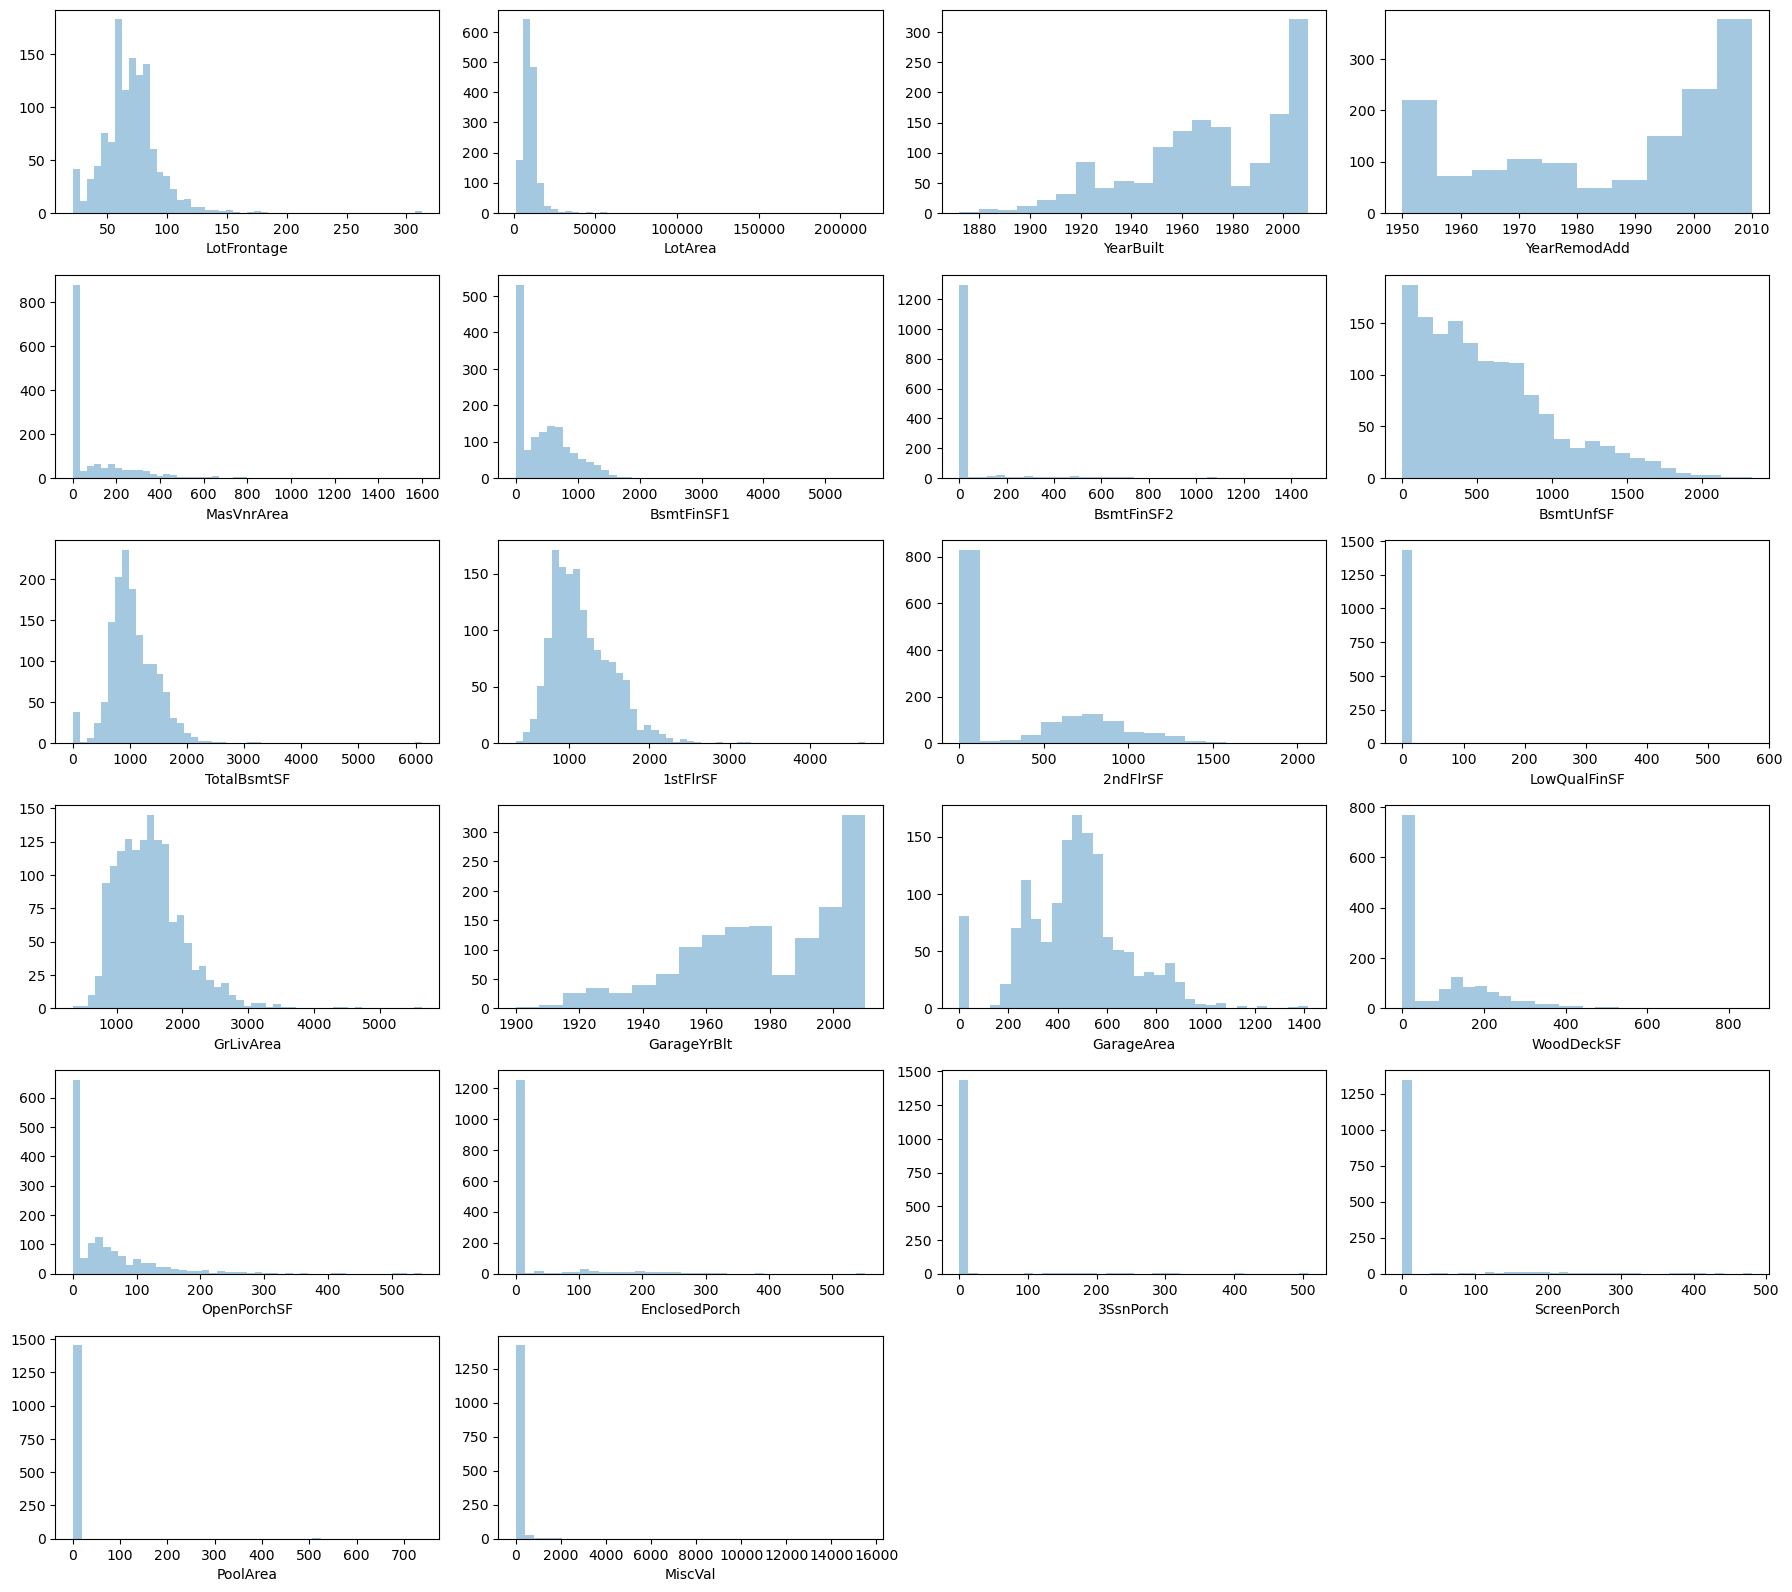

In [17]:
fig = plt.figure(figsize=(18, 16))

for i, col in enumerate(continuous_numeric_vars):
    plt.subplot(6, 4, i + 1)
    sns.distplot(numeric_X.loc[:, col].dropna(), kde=False)

fig.tight_layout(pad=1.0)

Certain variables have mostly a single value, such as:

- BsmtFinSF2
- LowQualFinSF
- EnclosedPorch
- 3SsnPorch
- ScreenPorch
- PoolArea
- MiscVal

The above features are highly skewed with mostly 0s. Since having a lot of 0s does not add much information to our prediction, we will remove them.

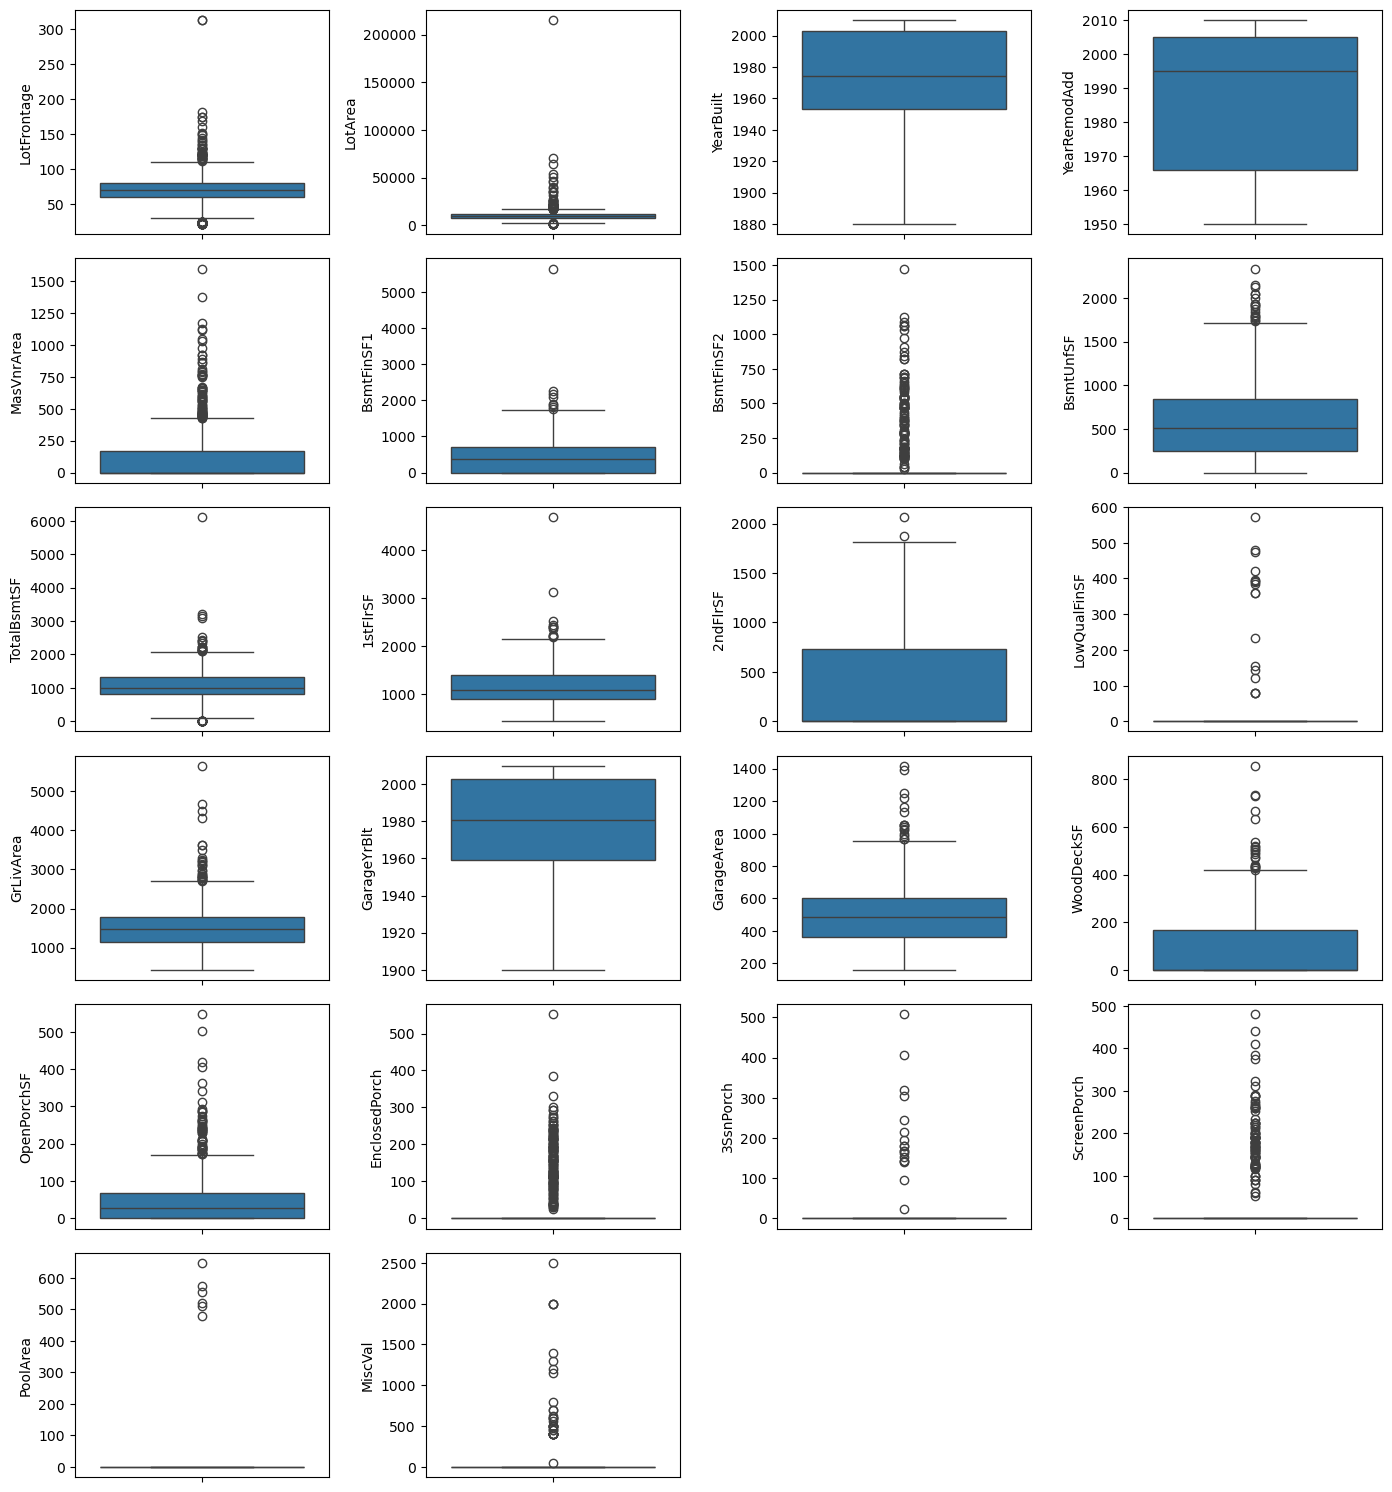

In [18]:
fig = plt.figure(figsize=(14,15))
for i, col in enumerate(continuous_numeric_vars):
    plt.subplot(6,4,i + 1)
    sns.boxplot(y=col, data=numeric_X.dropna())
fig.tight_layout(pad=1.0)

C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\3523185445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=numeric_X.dropna(), palette="Set2")
C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\3523185445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=numeric_X.dropna(), palette="Set2")
C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\3523185445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=numeric_X.dropna(), palette="Set2")
C:\Users\Dev\AppData\Local\Temp\ipykernel_30332\3523185445.py:4:

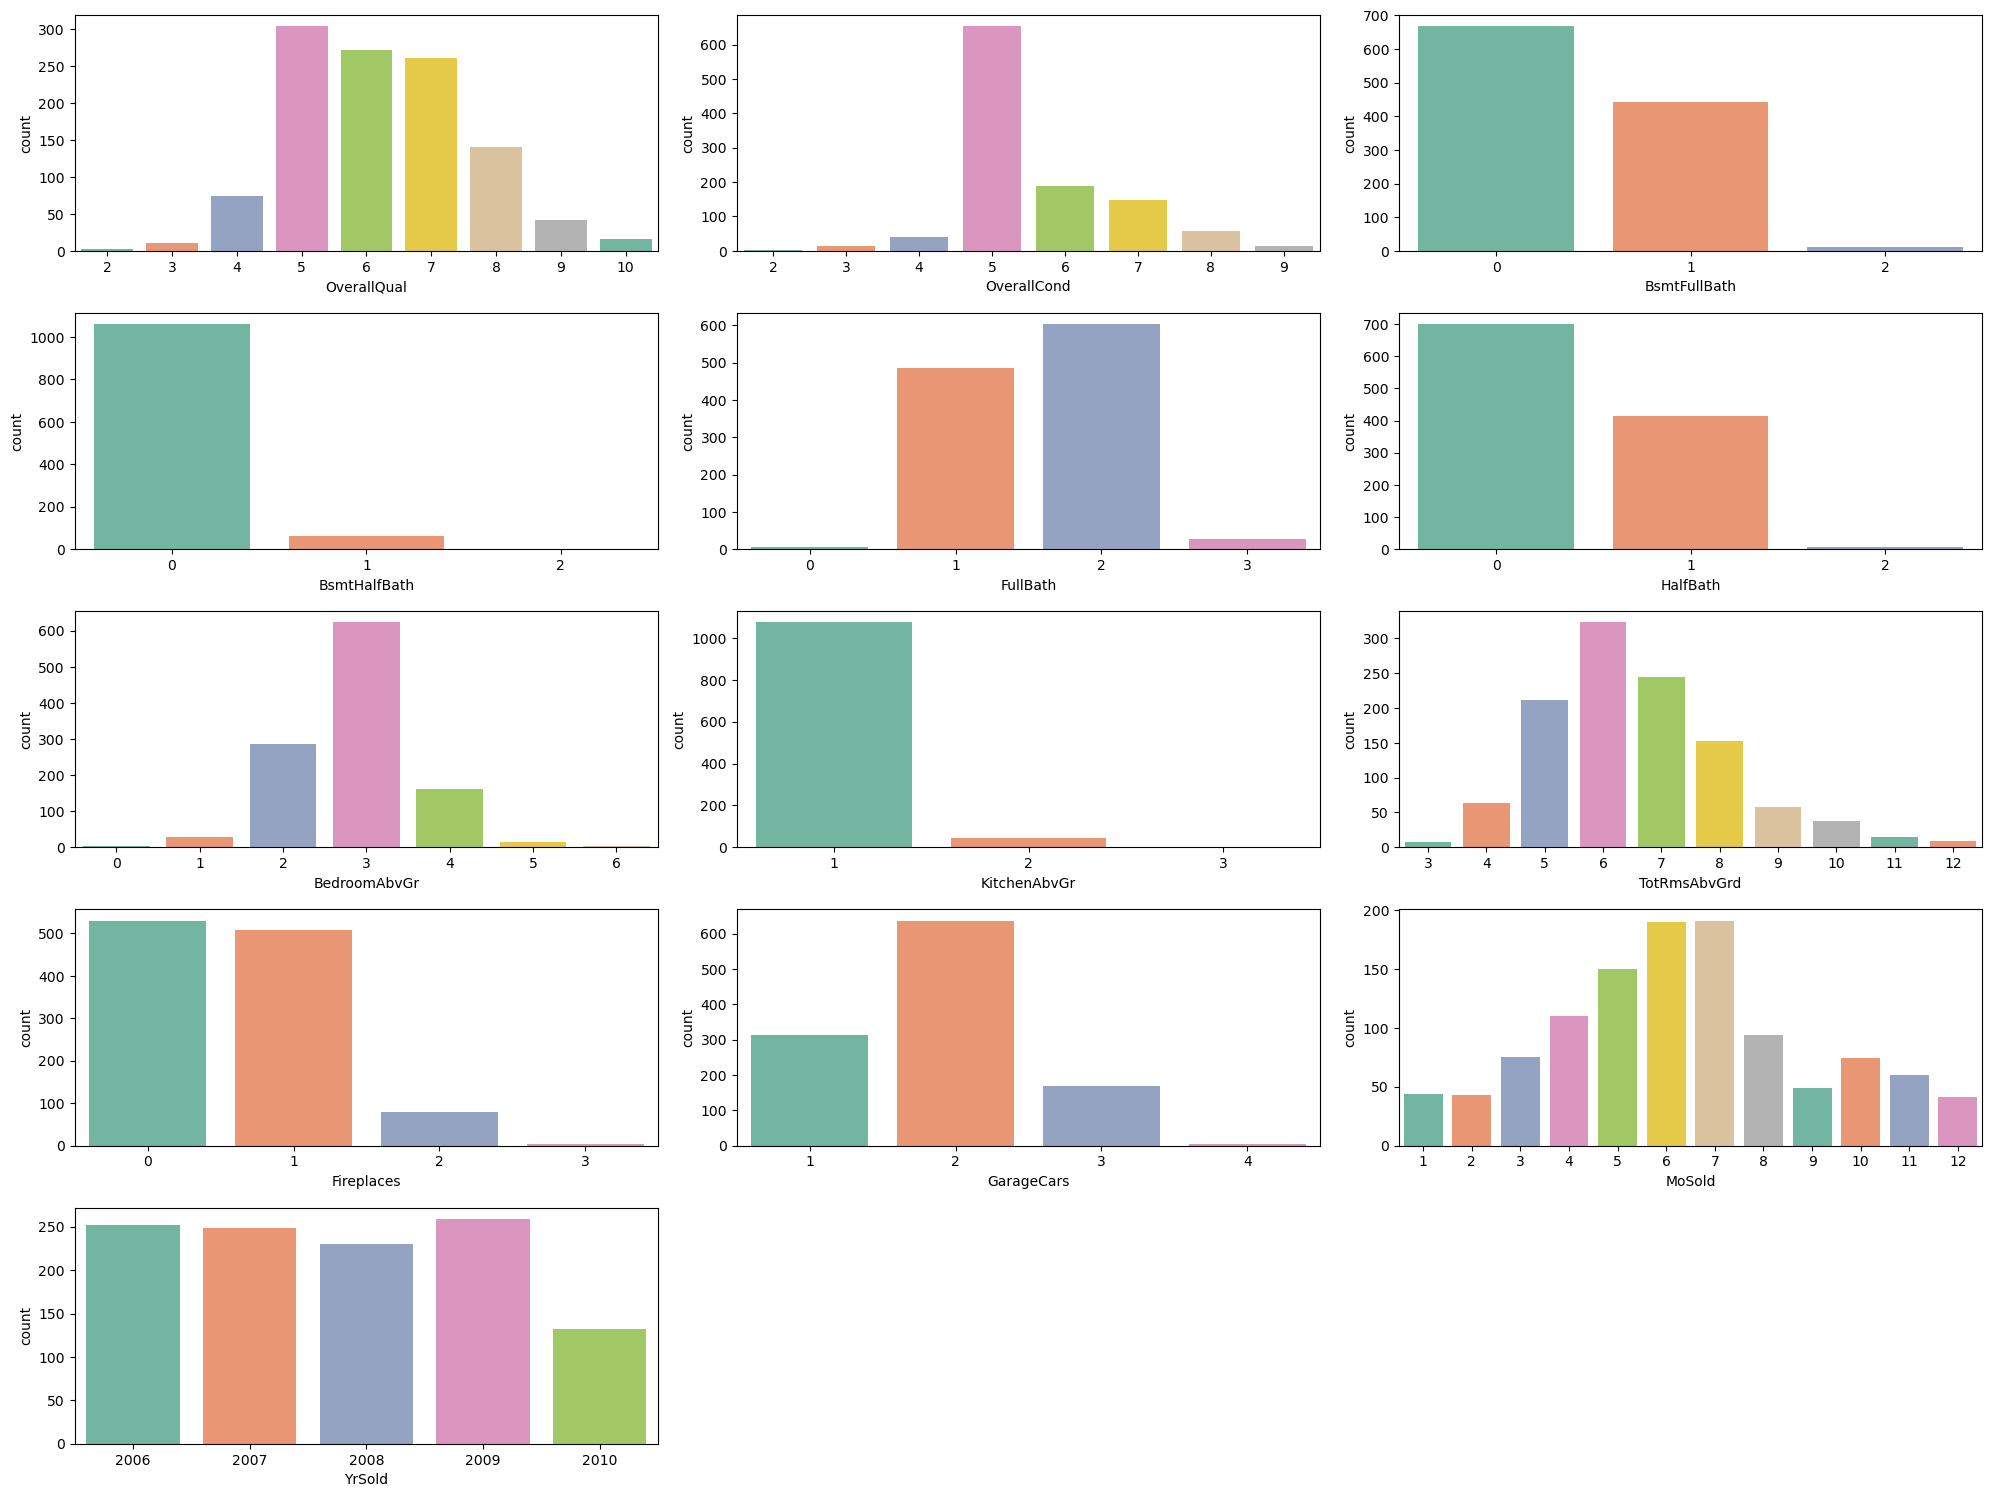

In [24]:
fig = plt.figure(figsize=(20,15))
for i, col in enumerate(ordinal_numeric_vars):
    plt.subplot(5,3,i + 1)
    sns.countplot(x=col, data=numeric_X.dropna(), palette="Set2")
fig.tight_layout(pad=1.0)